# Aayush

In [2]:
import numpy as np
import collections
import matplotlib.pyplot as plt
import time

%matplotlib inline

## defining game model and probabilities

the game state is defined by three variables:
* $i$ = my current total score
* $j$ = my opponent's total score
* $k$ = my current turn total

the game ends when $i+k \ge 100$ (i hold and win) or $j \ge 100$ (opponent has already won).

a single roll has $6 \times 6 = 36$ possible outcomes. we can group these into three critical events:

1.  **double 6 (reset total score):** a roll of (6, 6).
    * **outcome:** the player's *total score* $i$ resets to 0. the turn ends.
    * **probability:** $P(\text{double 6}) = \frac{1}{36}$

2.  **single 6 (lose turn score):** a roll with exactly one 6. (e.g., (6, 1), (1, 6), ...).
    * **outcome:** the player's *turn total* $k$ resets to 0. the turn ends.
    * **probability:** $P(\text{single 6}) = \frac{10}{36}$

3.  **good roll (continue turn):** a roll with no 6s. (e.g., (1, 1), (1, 2)... (5, 5)).
    * **outcome:** the sum of the dice, $s$, is added to the turn total: $k \leftarrow k+s$. the turn continues.
    * **probability:** $P(\text{good roll}) = \frac{25}{36}$


In [3]:
WIN_SCORE = 100
T_MAX = 100
EPS = 1e-10
MAX_ITERS = 5000

P_DOUBLE_6 = 1.0 / 36.0
P_SINGLE_6 = 10.0 / 36.0
P_GOOD_ROLL = 25.0 / 36.0

good_roll_sum_counts = collections.defaultdict(int)
for x in range(1, 6):
    for y in range(1, 6):
        good_roll_sum_counts[x + y] += 1

print(f"Using WIN_SCORE={WIN_SCORE}, T_MAX={T_MAX}")
print(f"P(Double 6): {P_DOUBLE_6:.4f} (Reset total score)")
print(f"P(Single 6): {P_SINGLE_6:.4f} (Lose turn score)")
print(f"P(Good Roll): {P_GOOD_ROLL:.4f} (Add to turn score)")
print(f"\nGood Roll Sum Counts (out of 25): {sorted(good_roll_sum_counts.items())}")

Using WIN_SCORE=100, T_MAX=100
P(Double 6): 0.0278 (Reset total score)
P(Single 6): 0.2778 (Lose turn score)
P(Good Roll): 0.6944 (Add to turn score)

Good Roll Sum Counts (out of 25): [(2, 1), (3, 2), (4, 3), (5, 4), (6, 5), (7, 4), (8, 3), (9, 2), (10, 1)]


## the value function

we define a 3D array, $V$, to store our **value function**. the value $V(i, j, k)$ represents the **maximum probability that the current player will win**, given the state $(i, j, k)$.

we also define `T_MAX`, a cap on the turn total $k$ we will track. This is a practical assumption to make the state space finite. we can do this because any rational player will always **hold** if $i+k \ge 100$, as this guarantees a win (win probability = 1.0). therefore, we only need to compute values for $k$ up to and slightly beyond this threshold.

we initialise this table with a neutral value (e.g., 0.5) and set the known **boundary conditions**:
* $V(i, j, k) = 1.0$ if $i+k \ge 100$ (i can hold and win)
* $V(i, j, k) = 0.0$ if $j \ge 100$ (opponent has already won)


In [4]:
# V[i, j, k] = win prob for current player from state (i, j, k)
V = np.full((WIN_SCORE, WIN_SCORE, T_MAX + 1), 0.5, dtype=float)

print(f"Init V table with shape: {V.shape}")

Init V table with shape: (100, 100, 101)


## Bellman Equation and Value Iteration

we repeatedly sweep the state space, applying the **bellman optimality equation** to update our estimate of $V(i, j, k)$ until the values converge.

the equation is:
$$
V(i, j, k) = \max\big( \text{Value}(\text{Hold}), \text{Value}(\text{Roll}) \big)
$$

### 1. Value(Hold)
if I **Hold**, my turn ends. my score becomes $i' = i + k$. it is now my opponent's turn. we assume the opponent also plays optimally, so their win probability from the new state $(j, i', 0)$ is $V(j, i', 0)$. my win probability is therefore 1 minus theirs:
$$
\text{Value}(\text{Hold}) = 1.0 - V(j, \min(i+k, 99), 0)
$$

### 2. Value(Roll)
if I **Roll**, my win probability is:
$$
\begin{aligned}
\text{Value}(\text{roll}) = & \quad P(\text{double 6}) \times \underbrace{\big( 1.0 - V(j, 0, 0) \big)}_{\text{my score resets to 0}} \\
& + P(\text{single 6}) \times \underbrace{\big( 1.0 - V(j, i, 0) \big)}_{\text{my turn score resets to 0}} \\
& + \sum_{s \in \text{good rolls}} P(s) \times \underbrace{V(i, j, \min(k+s, T_{\text{MAX}}))}_{\text{my turn continues}}
\end{aligned}
$$

In [5]:
def iterate_sheep(V):
    """Performs one value-iteration sweep, updating V in-place."""
    delta = 0.0

    # backwards iteration over states
    for i in range(WIN_SCORE - 1, -1, -1):      # mine
        for j in range(WIN_SCORE - 1, -1, -1):  # yours
            for k in range(T_MAX, -1, -1):      # turn total

                old_v = V[i, j, k]

                if i + k >= WIN_SCORE: # hold + win?
                    new_v = 1.0

                # has my opponent already won?
                else:
                    hold_i_score = min(i + k, WIN_SCORE - 1)
                    value_hold = 1.0 - V[j, hold_i_score, 0]


                    # outcome: double 6. my score -> 0. opponent plays from (j, 0, 0)
                    prob_win_double_6 = 1.0 - V[j, 0, 0]
                    prob_win_single_6 = 1.0 - V[j, i, 0]


                    good_roll_ev = 0.0
                    for s, count in good_roll_sum_counts.items():
                        new_k = min(k + s, T_MAX)

                        # check if this new state is a winning one
                        if i + new_k >= WIN_SCORE:
                            good_roll_ev += count * 1.0
                        else:
                            good_roll_ev += count * V[i, j, new_k]

                    # total value of rolling is the weighted average
                    value_roll = (P_DOUBLE_6 * prob_win_double_6) + \
                                 (P_SINGLE_6 * prob_win_single_6) + \
                                 (good_roll_ev / 36.0)

                    # bellman optimality equation
                    new_v = max(value_hold, value_roll)

                V[i, j, k] = new_v
                dv = abs(old_v - new_v)
                if dv > delta:
                    delta = dv
    return delta

it = 0
start_time = time.time()
while it < MAX_ITERS:
    it += 1
    max_diff = iterate_sheep(V)

    if it % 10 == 0:
        print(f"Iteration {it}: Max Change = {max_diff:.2e}")

    if max_diff < EPS:
        break

end_time = time.time()
print(f"\n--- Convergence Reached ---")
print(f"Total Iterations: {it}")
print(f"Total Time: {end_time - start_time:.2f} seconds")
print(f"\nProbability of winning from (0, 0, 0): {V[0, 0, 0]:.4f}")

Iteration 10: Max Change = 1.82e-02
Iteration 20: Max Change = 6.96e-04
Iteration 30: Max Change = 3.20e-05
Iteration 40: Max Change = 2.13e-06
Iteration 50: Max Change = 1.45e-07
Iteration 60: Max Change = 9.80e-09
Iteration 70: Max Change = 6.65e-10

--- Convergence Reached ---
Total Iterations: 78
Total Time: 342.11 seconds

Probability of winning from (0, 0, 0): 0.5140


## deriving the optimal policy

the `V` table now stores the converged *win probability* for the start of a turn, $V(i, j, 0)$. to get the final strategy, we must re-calculate the `Value(Hold)` vs. `Value(Roll)` decision for all turn totals $k$.

We can simplify this into a 2D **policy table**, `Strategy_Hold_At_K[i, j]`. this table stores the smallest turn total $k^*$ (the "hold threshold") for which holding is the better option:
$$
\text{Value}(\text{Hold}) \ge \text{Value}(\text{Roll})
$$
For any game state $(i, j)$:
* if your turn total $k < k^*$, you should **ROLL**.
* if your turn total $k \ge k^*$, you should **HOLD**.

In [6]:
# Strategy_Hold_At_K[i, j] = k
# if my score is i and opp is j, roll until turn total is k and then hold."
Strategy_Hold_At_K = np.zeros((WIN_SCORE, WIN_SCORE), dtype=int)

print("Calculating 2D Strategy Policy from 3D V-Table...")

for i in range(WIN_SCORE):
    for j in range(WIN_SCORE):
        # find the first k where hold >= roll
        for k in range(T_MAX + 1):

            # re-calculate the hold/roll values
            # V[i,j,k] already keeps the max of the two)

            # can i hold and win
            if i + k >= WIN_SCORE:
                Strategy_Hold_At_K[i, j] = k
                break

            hold_i_score = min(i + k, WIN_SCORE - 1)
            value_hold = 1.0 - V[j, hold_i_score, 0]

            prob_win_double_6 = 1.0 - V[j, 0, 0]
            prob_win_single_6 = 1.0 - V[j, i, 0]

            good_roll_ev = 0.0
            for s, count in good_roll_sum_counts.items():
                new_k = min(k + s, T_MAX)
                if i + new_k >= WIN_SCORE:
                    good_roll_ev += count * 1.0
                else:
                    good_roll_ev += count * V[i, j, new_k]

            value_roll = (P_DOUBLE_6 * prob_win_double_6) + \
                         (P_SINGLE_6 * prob_win_single_6) + \
                         (good_roll_ev / 36.0)

            if value_hold >= value_roll:
                Strategy_Hold_At_K[i, j] = k
                break
        else:
            # if never hold (e.g., opponent is at 99), set to T_MAX
            Strategy_Hold_At_K[i, j] = T_MAX


Calculating 2D Strategy Policy from 3D V-Table...


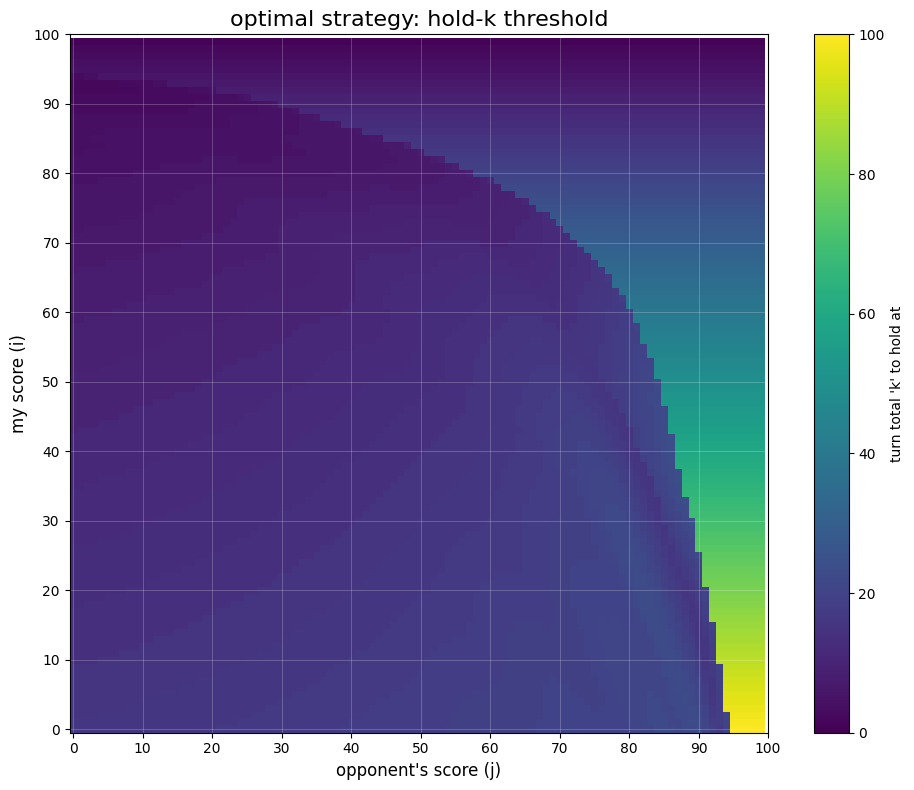

In [7]:
plt.figure(figsize=(10, 8))
plt.imshow(Strategy_Hold_At_K, origin='lower', cmap='viridis',
           vmin=0, vmax=Strategy_Hold_At_K.max())

plt.title("optimal strategy: hold-k threshold", fontsize=16)
plt.ylabel("my score (i)", fontsize=12)
plt.xlabel("opponent's score (j)", fontsize=12)

plt.xticks(np.arange(0, 101, 10))
plt.yticks(np.arange(0, 101, 10))
plt.grid(which='both', color='white', linestyle='-', linewidth=0.5, alpha=0.3)

plt.colorbar(label="turn total 'k' to hold at")
plt.tight_layout()
plt.show()

# just index Strategy_Hold_At_K[i, j] to get k

# New Analysis

## Playable Table from Optimal Policy

The optimal heat map is too detailed and not conducive to "memorization" and "on-the-spot application". We divide "s" into 4 segments and "the score difference d = s - o" into 5 segments. Then, in each small cell, we only retain one representative threshold (the median), and we obtain a 4×5 "playable table".

Table 1. Game phases and strategic tendencies in the Sheep dice game

\begin{array}{l l l}
\hline
\textbf{Score range ($s$)} & \textbf{Game phase} & \textbf{Strategic tendency} \\
\hline
0\text{--}39   & \text{Early game}   & \text{Low risk; build base score, roll moderately.} \\
40\text{--}69  & \text{Mid game}     & \text{Balanced risk--reward; thresholds near fixed optima.} \\
70\text{--}89  & \text{Late game}    & \text{More cautious; reduce threshold to avoid double--6 loss.} \\
90\text{--}99  & \text{End game}      & \text{Very conservative; cap threshold at remaining points to win.} \\
\hline
\end{array}


The score differences d are classified into five major categories: $d≤ -20$, $-19≤d≤-10$, $-9≤d≤9$,$10≤d≤19$, $d≥20$.

In [80]:
# STEP 1 — Define coarse bins for summarising the optimal heatmap
S_BINS = [(0, 39), (40, 69), (70, 89), (90, 99)]       # rows: my score i
D_BINS = [(-999, -20), (-19, -10), (-9, 9), (10, 19), (20, 999)]  # cols: d = i - j

# Safety clamp for playable thresholds
H_MIN, H_MAX = 0, 30


In [81]:
# STEP 2 — Helpers: locate a bin and round to human-friendly ticks
def locate_bin_s(i):
    """Return row index for my score i."""
    for idx, (lo, hi) in enumerate(S_BINS):
        if lo <= i <= hi:
            return idx
    return None

def locate_bin_d(i, j):
    """Return column index for score difference d = i - j."""
    d = i - j
    for idx, (lo, hi) in enumerate(D_BINS):
        if lo <= d <= hi:
            return idx
    return None

def round_to_1_or_5(x):
    """
    Round x to the nearest integer OR nearest multiple of 5.
    If tie, prefer the multiple of 5 (easier to remember).
    """
    nearest_int = int(round(x))
    nearest_5   = int(round(x / 5.0) * 5)
    if abs(x - nearest_5) < abs(x - nearest_int):
        return nearest_5
    if abs(x - nearest_5) > abs(x - nearest_int):
        return nearest_int
    return nearest_5

In [82]:
# STEP 3 — Collapse Strategy_Hold_At_K into a small 4x5 table via medians
import numpy as np
from collections import defaultdict
from statistics import median

def build_playable_table_from_kstar(k_star):
    """
    k_star: 2D array (100x100), e.g. your Strategy_Hold_At_K.
    returns: playable table with shape (len(S_BINS), len(D_BINS)).
    """
    buckets = defaultdict(list)
    # 3a) group values by (row-bin, col-bin)
    for i in range(WIN_SCORE):
        for j in range(WIN_SCORE):
            si = locate_bin_s(i); di = locate_bin_d(i, j)
            if si is None or di is None:
                continue
            buckets[(si, di)].append(int(k_star[i, j]))

    # 3b) take median in each bucket, round, and clamp
    table = np.zeros((len(S_BINS), len(D_BINS)), dtype=int)
    for si in range(len(S_BINS)):
        for di in range(len(D_BINS)):
            vals = buckets.get((si, di), [])
            if not vals:
                h = 16  # safe fallback
            else:
                h = round_to_1_or_5(median(vals))
            table[si, di] = int(np.clip(h, H_MIN, H_MAX))
    return table

play_table_raw = build_playable_table_from_kstar(Strategy_Hold_At_K)
#print("Raw playable table (rows=S_BINS, cols=D_BINS):")
#print(play_table_raw)

# === Display the 4x5 playable table (clean version, no color) ===
import pandas as pd
from IPython.display import display

def show_playable_table_clean(table):
    """
    Display the playable threshold table as a clean, text-based table.
    No color, just clear labels for report use.
    """
    # Row and column labels
    row_labels = [f"[{lo},{hi}]" for (lo, hi) in S_BINS]
    col_labels = [f"[{lo},{hi}]" for (lo, hi) in D_BINS]

    # Create DataFrame
    df = pd.DataFrame(table, index=row_labels, columns=col_labels)
    df.index.name = "My total score s "
    df.columns.name = "Score difference "

    # Optional: set integer format, for cleaner look
    pd.options.display.float_format = "{:.0f}".format

    # Print as markdown-like text table
    print("\n=== Playable Threshold Table (H values) ===")
    display(df)

# Show the table
show_playable_table_clean(play_table_raw)



=== Playable Threshold Table (H values) ===


Score difference,"[-999,-20]","[-19,-10]","[-9,9]","[10,19]","[20,999]"
My total score s,,,,,
"[0,39]",19,15,14,13,12
"[40,69]",30,16,13,12,10
"[70,89]",27,23,18,13,7
"[90,99]",16,16,6,5,4


## Fixed K Policy

Each simulation of the probability will vary, making it difficult to intuitively determine which K has the highest winning probability.

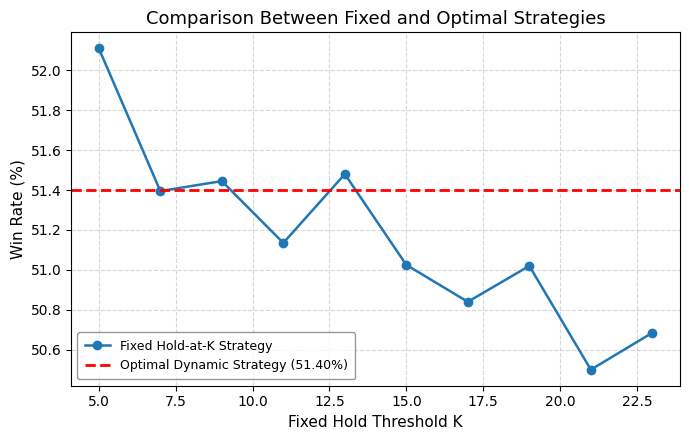

Best fixed strategy: Hold at 5, win rate = 52.11%
Optimal dynamic strategy win rate = 51.40%


In [76]:
import numpy as np
import random
import matplotlib.pyplot as plt

NUM_GAMES = 20000
WIN_SCORE = 100

def roll_dice():
    return random.randint(1, 6), random.randint(1, 6)

def play_game_with_policy(policy_func):
    my_score, opp_score = 0, 0
    while my_score < WIN_SCORE and opp_score < WIN_SCORE:
        # My turn
        turn_total = 0
        while True:
            hold_k = policy_func(my_score, opp_score, turn_total)
            if hold_k:  # True = Hold
                my_score += turn_total
                break

            d1, d2 = roll_dice()
            if d1 == 6 and d2 == 6:
                my_score = 0
                break
            elif d1 == 6 or d2 == 6:
                turn_total = 0
                break
            else:
                turn_total += d1 + d2
                if my_score + turn_total >= WIN_SCORE:
                    my_score += turn_total
                    break

        if my_score >= WIN_SCORE:
            break

        # Opponent's turn
        turn_total = 0
        while True:
            hold_k = policy_func(opp_score, my_score, turn_total)
            if hold_k:
                opp_score += turn_total
                break

            d1, d2 = roll_dice()
            if d1 == 6 and d2 == 6:
                opp_score = 0
                break
            elif d1 == 6 or d2 == 6:
                turn_total = 0
                break
            else:
                turn_total += d1 + d2
                if opp_score + turn_total >= WIN_SCORE:
                    opp_score += turn_total
                    break

    return 1 if my_score >= WIN_SCORE else 0

def optimal_policy(i, j, k):
    return k >= Strategy_Hold_At_K[i, j]  # True = Hold

def fixed_policy_generator(K):
    def fixed_policy(i, j, k):
        return k >= K
    return fixed_policy


Ks = list(range(5, 25, 2))
win_rates = []

for K in Ks:
    fixed_policy = fixed_policy_generator(K)
    wins = [play_game_with_policy(fixed_policy) for _ in range(NUM_GAMES)]
    win_rates.append(np.mean(wins))


win_rate_optimal = 0.514


plt.figure(figsize=(7, 4.5))
plt.plot(Ks, [w * 100 for w in win_rates], 'o-', label='Fixed Hold-at-K Strategy', linewidth=1.8)
plt.axhline(win_rate_optimal * 100, color='red', linestyle='--', linewidth=2,
            label=f'Optimal Dynamic Strategy ({win_rate_optimal*100:.2f}%)')

plt.xlabel("Fixed Hold Threshold K", fontsize=11)
plt.ylabel("Win Rate (%)", fontsize=11)
plt.title("Comparison Between Fixed and Optimal Strategies", fontsize=13)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(
    loc='lower left',
    fontsize=9,
    frameon=True,
    framealpha=0.8,
    borderpad=0.6,
    labelspacing=0.5,
    edgecolor='gray'
)
plt.tight_layout()
plt.show()

best_fixed_idx = np.argmax(win_rates)
print(f"Best fixed strategy: Hold at {Ks[best_fixed_idx]}, win rate = {win_rates[best_fixed_idx]*100:.2f}%")
print(f"Optimal dynamic strategy win rate = {win_rate_optimal*100:.2f}%")


## Explore more playable method

If ignore the opponent's score:
$$E(S, T) = \frac{25}{36}*6 - \frac{10}{36}*t - \frac{1}{36}*(s + t)$$
We want $E(S, T) ≥ 0$, so if $t > \frac{150 - s}{11}$ $(E < 0)$, we will choose HOLD.

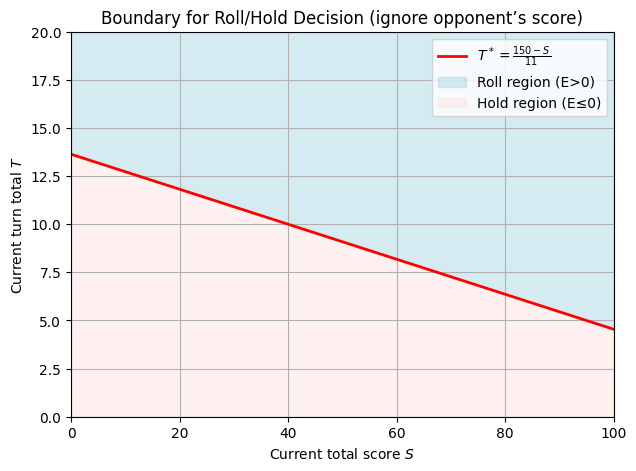

In [79]:
# If ignore the opponent's score:
#
#     E(S, T) = (25/36)*6 - (10/36)*t - (1/36)*(s + t)
#
# We want E(S, T) ≥ 0, so if t > (150 - s)/11 (E < 0), we will choose HOLD.

import numpy as np
import matplotlib.pyplot as plt

# T = (150 - S)/11
S = np.linspace(0, 100, 200)
T_star = (150 - S) / 11

# 绘图
plt.figure(figsize=(7,5))
plt.plot(S, T_star, 'r-', linewidth=2, label=r'$T^* = \frac{150 - S}{11}$')
plt.fill_between(S, T_star, 20, color='lightblue', alpha=0.5, label='Roll region (E>0)')
plt.fill_between(S, 0, T_star, color='mistyrose', alpha=0.5, label='Hold region (E≤0)')

plt.xlabel("Current total score $S$")
plt.ylabel("Current turn total $T$")
plt.title("Boundary for Roll/Hold Decision (ignore opponent’s score)")
plt.legend()
plt.grid(True)
plt.xlim(0, 100)
plt.ylim(0, 20)
plt.show()


Now, we introduce the opponent's score o and modify the threshold to depend on the score difference o-s  
$$T^\star(s,o)=\frac{150-s+ α* (o-s)}{11},  (α> 0) $$

This satisfy:

*   lag behind $(o-s > 0)$, raise the $T^\star$, play more aggressively
*   ahead $(o-s < 0)$, lower the $T^\star$, play more conservatively

To make the strategy more playable and easier to implement without continuous calculation, we discretise the score difference $d=o−s$ into several ranges rather than using the continuous linear adjustment:


| Score difference $d=o-s$ | Interpretation |
|:-------------------------------|:--------------------------------|
| $d \le -20$   | Far ahead |
| $-19 \le d \le -10$     | Moderately ahead |
| $-9 \le d \le 9$     | Close game |
| $10 \le d \le 19$   | Moderately behind |
| $d \ge 20$    | Far behind |


For each interval, we define an integer adjustment $Δ(d)$ applied to the base threshold  
$T_{\text{base}}(s) = \frac{150 - s}{11}$:

$$
T^\star_{\text{playable}}(s,o)
= T_{\text{base}}(s) + \Delta(d), \quad d = o - s
$$

To determine the adjustment values $ \Delta(d) $, we use the Dynamic Programming (DP) results as a reference.  
For each score range s and score difference interval \(d\), we compute the **median deviation** between the DP‐optimal hold threshold and the baseline threshold:

$$
\Delta(d,s)
= \text{median}_{(s,o)\in\text{bin}}
\big(\text{Threshold_DP}[s,o] - \text{round}(T_{\text{base}}(s))\big)
$$

The resulting integer values are then rounded and clipped to a small range (−3 to +3) to maintain playability.  


In [86]:
import numpy as np

# --- INPUT ---
# Strategy_Hold_At_K: np.ndarray shape (100,100)
# Example: Strategy_Hold_At_K = np.load('Strategy_Hold_At_K.npy')

# Bins (merged -9..9 into one bin)
S_BINS = [(0,39), (40,69), (70,89), (90,99)]  # my score ranges
D_BINS = [(-10**9,-20), (-19,-10), (-9,9), (10,19), (20,10**9)]  # merged close game bin
CLIP = (-3, 3)  # keep deltas small and playable

def T_base(s: int) -> float:
    """Baseline threshold as a function of my score s."""
    return (150 - s) / 11.0

def calibrate_delta_table(k_dp: np.ndarray,
                          s_bins=S_BINS, d_bins=D_BINS,
                          clip=CLIP, use_median=True) -> np.ndarray:
    """
    For each (s-bin, d-bin), compute Δ = median_{(s,o) in bin}[ k_dp[s,o] - round(T_base(s)) ].
    Return a 2D integer array with shape (len(s_bins), len(d_bins)).
    """
    WIN = k_dp.shape[0]
    deltas = np.zeros((len(s_bins), len(d_bins)), dtype=int)

    for si, (s_lo, s_hi) in enumerate(s_bins):
        s_lo, s_hi = max(0, s_lo), min(WIN-1, s_hi)
        for di, (d_lo, d_hi) in enumerate(d_bins):
            residuals = []
            for s in range(s_lo, s_hi+1):
                base_int = int(round(T_base(s)))
                o_lo = max(0, min(WIN-1, s + d_lo))
                o_hi = max(0, min(WIN-1, s + d_hi))
                if o_lo > o_hi:
                    continue
                residuals.extend((k_dp[s, o_lo:o_hi+1] - base_int).tolist())

            if residuals:
                val = np.median(residuals) if use_median else np.mean(residuals)
                val = int(np.rint(val))
                val = max(clip[0], min(clip[1], val))
            else:
                val = 0
            deltas[si, di] = val
    return deltas

# ---- RUN ----
delta_table = calibrate_delta_table(Strategy_Hold_At_K, S_BINS, D_BINS, CLIP)
print("Δ(d) per (s-bin × d-bin):")
for (s_lo, s_hi), row in zip(S_BINS, delta_table):
    print(f"s in [{s_lo},{s_hi}]: {row.tolist()}")

# Optional: playable threshold function
def playable_H_from_table(s:int, o:int, delta_table:np.ndarray,
                          s_bins=S_BINS, d_bins=D_BINS,
                          Hmin=4, Hmax=25) -> int:
    """H = round(T_base(s)) + Δ(s-bin, d-bin), then clipped."""
    si = next(i for i,(lo,hi) in enumerate(s_bins) if lo <= s <= hi)
    d = o - s
    di = next(i for i,(lo,hi) in enumerate(d_bins) if lo <= d <= hi)
    H = int(round(T_base(s))) + int(delta_table[si, di])
    return max(Hmin, min(Hmax, H))


Δ(d) per (s-bin × d-bin):
s in [0,39]: [-2, -1, 0, 1, 3]
s in [40,69]: [-3, -1, 0, 1, 3]
s in [70,89]: [-3, -1, 0, 1, 2]
s in [90,99]: [-3, -1, 0, 0, 0]


### General Playable Rules

Start from the baseline threshold:
$$
H_{\text{base}}(s) = \text{round}\!\left(\frac{150 - s}{11}\right)
$$

and adjust it by the score difference $d = o - s$:

- Behind by **≈10 pts / 20 pts** → $ \Delta(d) \approx +1 / +2$ ( up to +3 early)
- Ahead by **≈10 pts / 20 pts** → $ \Delta(d) \approx -1 / -2$ (sometimes −3)
- Close game ($|d| \le 9$) → $ \Delta(d) = 0 $

When $ s \ge 90 $, enter a **conservative phase**:  
no further increase when behind,  
and slightly decrease when ahead ($ \Delta \approx -1 $).

Final rule:
$$
H_{\text{playable}}(s,o)
= H_{\text{base}}(s) + \Delta(d), \quad H \in [4,25].
$$
